# 1. ETL - Extract, Transform and Load


## 1.1 Library import


In [668]:
import pandas as pd

## 1.2 Data extraction

- CSV loading


In [669]:
url_1k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/1k.csv"
url_2k = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/2k.csv"
url_4k7 = "https://raw.githubusercontent.com/import-tiago/FEI/refs/heads/main/MSc/PEL309/Data/4k7.csv"

raw_1k_csv = pd.read_fwf(url_1k, header=None, skip_blank_lines=False)
raw_2k_csv = pd.read_fwf(url_2k, header=None, skip_blank_lines=False)
raw_4k7_csv = pd.read_fwf(url_4k7, header=None, skip_blank_lines=False)


## 1.3 Raw data inspection

- File preview
- Shape inspection
- Sample count verification


In [670]:
preview = raw_1k_csv.head(20)
print(preview.to_string(index=False, header=False))


                                                  Model,MSO46B
                                      Channel,CH1,,Channel,CH2
                                                Label,,,Label,
                    Waveform Type,ANALOG,,Waveform Type,ANALOG
                          Digital Type,None,,Digital Type,None
                        Horizontal Units,s,,Horizontal Units,s
Sample Interval,8.00000000e-05,,Sample Interval,8.00000000e-05
                    Record Length,148144,,Record Length,148144
          Zero Index,23143.00000000,,Zero Index,23143.00000000
                            Vertical Units,V,,Vertical Units,V
                                                          ,,,,
                          ANALOG_Thumbnail,,,ANALOG_Thumbnail,
                            yOffset,0.000000,,yOffset,0.000000
                        yPosition,0.000000,,yPosition,0.180000
                                                           NaN
                                                      L

In [671]:
pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "raw_shape": [raw_1k_csv.shape, raw_2k_csv.shape, raw_4k7_csv.shape],
})


,load,raw_shape
0,1k,"(148161, 1)"
1,2k,"(151089, 1)"
2,4k7,"(107745, 1)"


## 1.4 Column selection and dataset naming

- Column selection
- Dataset naming


In [672]:
# Carga de 1000 Ω
data_1k_load = pd.read_csv(url_1k, skiprows=17, usecols=[1, 2])
data_1k_load.columns = ["dac_volts", "shunt_volts"]
data_1k_load["sample"] = data_1k_load.index

# Carga de 2000 Ω
data_2k_load = pd.read_csv(url_2k, skiprows=17, usecols=[1, 2])
data_2k_load.columns = ["dac_volts", "shunt_volts"]
data_2k_load["sample"] = data_2k_load.index

# Carga de 4700 Ω
data_4k7_load = pd.read_csv(url_4k7, skiprows=17, usecols=[1, 2])
data_4k7_load.columns = ["dac_volts", "shunt_volts"]
data_4k7_load["sample"] = data_4k7_load.index

In [673]:
pd.DataFrame({
    "load": ["1k", "2k", "4k7"],
    "shape": [data_1k_load.shape, data_2k_load.shape, data_4k7_load.shape],
})


,load,shape
0,1k,"(148143, 3)"
1,2k,"(151071, 3)"
2,4k7,"(107727, 3)"


Text(0, 0.5, 'voltage (V)')

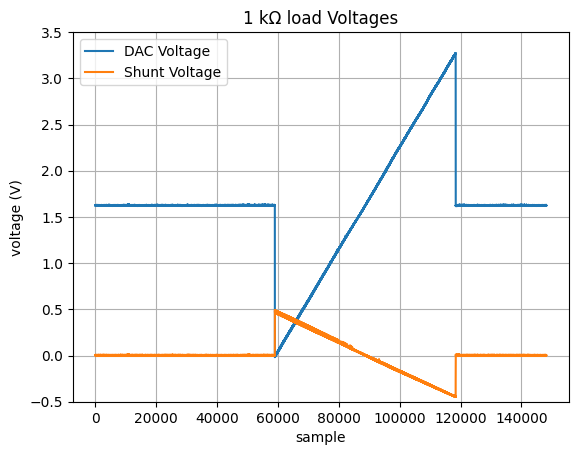

In [674]:
ax = data_1k_load.rename(columns={
    "dac_volts": "DAC Voltage",
    "shunt_volts": "Shunt Voltage"
}).plot(
    title="1 kΩ load Voltages",
    x="sample",
    y=["DAC Voltage", "Shunt Voltage"],
    grid=True,
    ylim=(-0.5, 3.5)
)

ax.set_xlabel("sample")
ax.set_ylabel("voltage (V)")

## 1.5 Signal transformation

- Ramp region extraction
- Stationary region removal
- Time alignment
- Sample count equalization


In [675]:
# Detecta região de rampa (ou, remove "regime em repouso") a partir de variação abrupta no DAC (indicando início e fim da rampa)

def extract_ramp_region(df, column, trigger_threshold):

    data = df.copy()

    diff = data[column].diff().abs()

    transition_points = diff[diff > trigger_threshold].index

    discarded_points = 512

    start = transition_points[0] + discarded_points
    end = transition_points[-1] - discarded_points

    return data.loc[start:end].copy()


def equalize_sample_count(*dfs):
    
    sample_count = min(len(df) for df in dfs)
    aligned_dfs = []

    for df in dfs:
        aligned_df = df.iloc[:sample_count].reset_index(drop=True).copy()
        aligned_df["sample"] = aligned_df.index
        aligned_dfs.append(aligned_df)

    return aligned_dfs

In [676]:
# Analisa apenas a coluna DAC pois o importante é descobrir o índice de início e fim da rampa.
# Os índices obtidos aplicam-se também às séries do shunt, para manter a fase entre sinais.

data_1k_load = extract_ramp_region(data_1k_load, column="dac_volts", trigger_threshold=0.5)
data_2k_load = extract_ramp_region(data_2k_load, column="dac_volts", trigger_threshold=0.5)
data_4k7_load = extract_ramp_region(data_4k7_load, column="dac_volts", trigger_threshold=0.5)

data_1k_load, data_2k_load, data_4k7_load = equalize_sample_count(data_1k_load, data_2k_load, data_4k7_load)

pd.DataFrame({"load": ["1k", "2k", "4k7"], "samples": [len(data_1k_load), len(data_2k_load), len(data_4k7_load)]})

,load,samples
0,1k,58386
1,2k,58386
2,4k7,58386


## 1.6 Feature engineering

- Current computation
- DAC data binning

Text(0, 0.5, 'current (mA)')

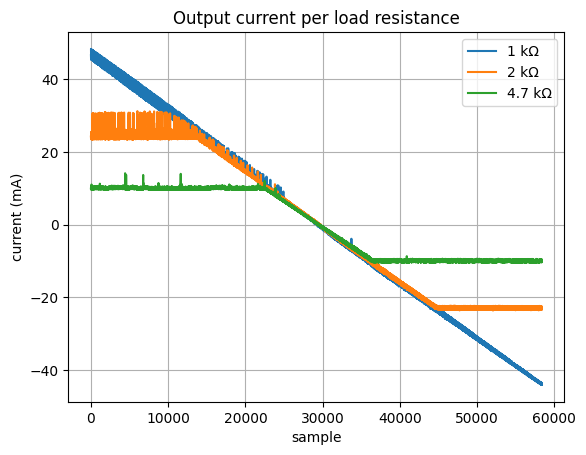

In [677]:
# A partir da tensão no shunt, calcula-se a corrente usando a lei de Ohm: I = V / R
# A corrente no shunt é a mesma da carga, dado que os dois estão em série.
# Multiplica-se por 1000 para converter de A para mA.

shunt_resistance = 10  # Ω

data_1k_load["current_mA"] = (data_1k_load["shunt_volts"] / shunt_resistance) * 1000
data_2k_load["current_mA"] = (data_2k_load["shunt_volts"] / shunt_resistance) * 1000
data_4k7_load["current_mA"] = (data_4k7_load["shunt_volts"] / shunt_resistance) * 1000

ax = data_1k_load.plot(x="sample", y="current_mA", grid=True, title="Output current per load resistance", label="1 kΩ")
data_2k_load.plot(x="sample", y="current_mA", ax=ax, label="2 kΩ", grid=True)
data_4k7_load.plot(x="sample", y="current_mA", ax=ax, label="4.7 kΩ", grid=True)

ax.set_xlabel("sample")
ax.set_ylabel("current (mA)")

## 1.7 Statistical aggregation

- Grouping by DAC bin
- Mean current estimation
- Pivot table generation


The DAC voltage was quantized using fixed-width quantization:

$$
V_{DAC,quantized} = \mathrm{round}\left(\frac{V_{DAC}}{\Delta V}\right) \cdot \Delta V
$$

where:

$$
\Delta V = 0.01\,V
$$


In [678]:
# Os valores de tensão do DAC foram agrupados em bins de 0,01 V,
# reduzindo a granularidade no domínio da tensão e 
# permitindo a agregação estatística de amostras em níveis equivalentes de DAC.

dac_step = 0.01  # passo de 10 mV para os bins de tensão do DAC

all_currents = pd.concat(
    [
        data_1k_load[["dac_volts", "current_mA"]].assign(load_value="1k"),
        data_2k_load[["dac_volts", "current_mA"]].assign(load_value="2k"),
        data_4k7_load[["dac_volts", "current_mA"]].assign(load_value="4k7"),
    ],
    ignore_index=True,
)

# O primeiro round() atribui cada valor de DAC ao bin mais próximo definido por dac_step.
# O round(2) final remove artefatos de ponto flutuante após multiplicar de volta pelo passo.
all_currents["dac_bin"] = ((all_currents["dac_volts"] / dac_step).round() * dac_step).round(2) #  fixed-width quantization


In [679]:
all_currents.head()

,dac_volts,current_mA,load_value,dac_bin
0,0.014687,46.626563,1k,0.01
1,0.014063,46.270313,1k,0.01
2,0.017812,46.409375,1k,0.02
3,0.014844,46.667187,1k,0.01
4,0.015156,46.270313,1k,0.02


In [680]:
all_currents.tail()

,dac_volts,current_mA,load_value,dac_bin
175153,3.245938,-10.323438,4k7,3.25
175154,3.240469,-9.884375,4k7,3.24
175155,3.240156,-9.953125,4k7,3.24
175156,3.242969,-10.279687,4k7,3.24
175157,3.244219,-10.156250,4k7,3.24


In [681]:
# Cria uma tabela de comparação indexada pelo bin de DAC.
# Cada carga vira uma coluna, e cada célula contém a corrente média
# das amostras que caíram no mesmo bin de DAC para aquela carga.
processed_current_data = all_currents.pivot_table(index="dac_bin", columns="load_value", values="current_mA", aggfunc="mean")
processed_current_data.head()

load_value,1k,2k,4k7
dac_bin,,,
0.01,45.911222,24.145882,9.911491
0.02,46.330384,24.310656,9.932422
0.03,46.122148,24.471661,9.954167
0.04,45.878822,24.520046,10.081883
0.05,45.556530,24.520062,10.074372


# EDA - Análise Exploratória dos Dados



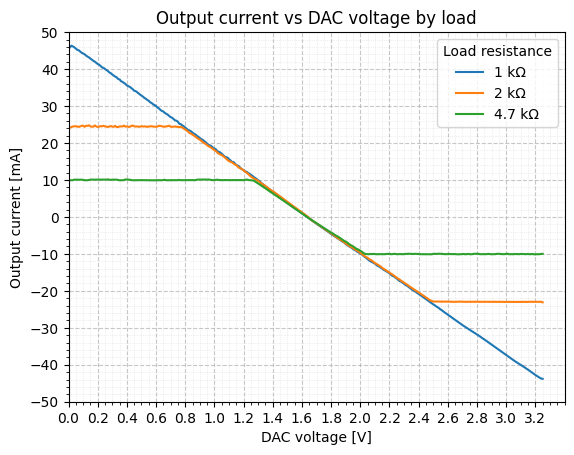

In [682]:
ax = processed_current_data.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.set_title("Output current vs DAC voltage by load")
ax.legend(title="Load resistance")
ax.legend(["1 kΩ", "2 kΩ", "4.7 kΩ"], title="Load resistance")

## Saturation removal based on theoretical current limits

The original `processed_current_data` is kept unchanged. The cells below create a new dataframe with the saturated regions removed from the 2 kΩ and 4.7 kΩ current signals.


In [683]:
# The FES output voltage is limited to approximately +/-48 V.
# Therefore, the theoretical saturation current is I = V / R.

fes_max_voltage = 48  # V

theoretical_saturation_current_mA = pd.Series(
    {
        "2k": (fes_max_voltage / 2000) * 1000,
        "4k7": (fes_max_voltage / 4700) * 1000,
    }
)

# A margin is used because measured saturation usually starts slightly before the ideal limit.
saturation_margin = 0.95

saturation_detection_limit_mA = theoretical_saturation_current_mA * saturation_margin
saturation_detection_limit_mA

2k     22.800000
4k7     9.702128
dtype: float64

In [ ]:
linear_current_data = processed_current_data.copy()

# 1k does not saturate in this measurement, so it is intentionally kept unchanged.
linear_current_data["2k"] = linear_current_data["2k"].where(
    linear_current_data["2k"].abs() < saturation_detection_limit_mA["2k"]
)

linear_current_data["4k7"] = linear_current_data["4k7"].where(
    linear_current_data["4k7"].abs() < saturation_detection_limit_mA["4k7"]
)

pd.DataFrame(
    {
        "theoretical_saturation_current_mA": theoretical_saturation_current_mA,
        "detection_limit_mA": saturation_detection_limit_mA,
        "removed_points": processed_current_data[["2k", "4k7"]].notna().sum() - linear_current_data[["2k", "4k7"]].notna().sum(),
        "remaining_points": linear_current_data[["2k", "4k7"]].notna().sum(),
    }
)

,theoretical_saturation_current_mA,detection_limit_mA,removed_points,remaining_points
2k,24.000000,22.800000,158,167
4k7,10.212766,9.702128,251,74


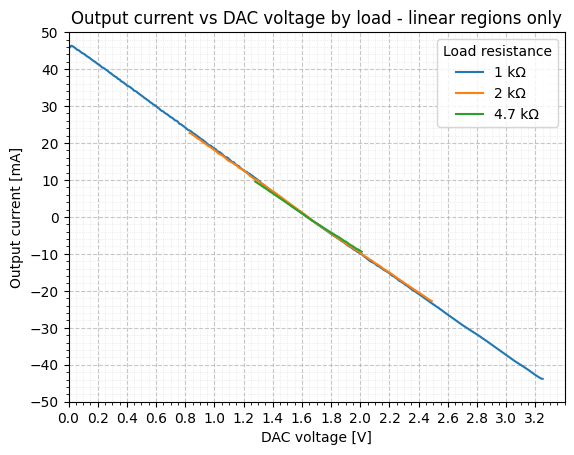

In [685]:
ax = linear_current_data.plot()

ax.set_xlim(0, 3.4)
ax.set_xticks([i / 10 for i in range(0, 34, 2)])

ax.set_ylim(-50, 50)
ax.set_yticks(range(-50, 51, 10))

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.minorticks_on()
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.4)

ax.set_xlabel("DAC voltage [V]")
ax.set_ylabel("Output current [mA]")
ax.set_title("Output current vs DAC voltage by load - linear regions only")
ax.legend(["1 kΩ", "2 kΩ", "4.7 kΩ"], title="Load resistance")
